# Computing the Church-to-Bar Ratio for Each U.S. State

The brighter the color, the higher the church-to-bar ratio.

## Method

From the latest (2023) [County Business Patterns](https://www.census.gov/programs-surveys/cbp.html) data published by the U.S. Census Bureau, I extracted the number of establishments in each state that have NAICS codes 813110 (places of worship including churches, temples, mosques, synagogues, etc.) and 722410 (bars, taverns, drink-serving nightclubs, etc.). For each state, I then divided the number of NAICS 813110 establishments by the number of NAICS 722410 establishments to get the "church to bar ratio". Finally, I partitioned the resulting ratio distribution into twelve color groups, and plotted each state’s ratio color on the map. Used log-transformed values when creating the partitions. Source code implementing these calculations is contained in the Jupyter notebook to facilitate peer review.

## Results

The "Bible Belt" shows up in brighter colors, as we'd expect.

## Possible bias in the result

If NAICS code 813110 excludes church facilities with unpaid staff and clergy—i.e., if the Census Bureau does not to consider them "places of industry" since no one is getting paid to work there—the LDS presence in the west will be severely underrepresented. This warrants further review of NAICS measurement methodology before producing future map updates. Reader comments on the appropriateness of NAICS industry codes for this study are very welcome!

## Load useful libraries

In [1]:
from pathlib import Path
import shutil
import cairosvg
from IPython.display import SVG

In [2]:
from python_tools_and_shortcuts.geography.united_states.Fips import FipsState
from CountyBusinessPatternsState import CountyBusinessPatternsState
from ChurchToBarRatioPerState import ChurchToBarRatioPerState

## User settings

In [3]:
#
# URLs for source data
#
url_per_state_cbp = 'https://www2.census.gov/programs-surveys/cbp/datasets/2023/cbp23st.zip'
url_fips_codes = 'https://www2.census.gov/geo/docs/reference/codes2020/national_county2020.txt'

#
# SVG map source data
#
filename_state_map_svg = 'data/' + 'Blank_US_Map_(states_only).svg'

#
# output directories and filenames
#
directory_output = 'output'  # will be deleted if it already exists

## Load the FIPS table

Federal Information Processing Standard (FIPS) uniquely identify U.S. states, territories, and counties. These are standardized across the United States government and managed by NIST.

In [4]:
fips = FipsState(url_fips_codes = url_fips_codes)
fips.download_FIPS_codes()
fips.df.head(3)

,STATE,STATEFP
0,AK,02
1,AL,01
2,AR,05


In [5]:
fips.timestamp_download

datetime.datetime(2026, 6, 22, 23, 34, 25, 985216, tzinfo=datetime.timezone.utc)

In [6]:
df_fips_codes = fips.df.copy() # for now

In [7]:
df_fips_codes.head(3)

,STATE,STATEFP
0,AK,02
1,AL,01
2,AR,05


## Clear and create the output directory

In [8]:
directory_path = Path(directory_output)

if directory_path.exists() and directory_path.is_dir():
    shutil.rmtree(directory_path)

directory_path.mkdir(parents=True, exist_ok=True)

## Load the state-level County Business Patterns data into a DataFrame

In [9]:
cbp = CountyBusinessPatternsState(url_per_state_cbp = url_per_state_cbp)
cbp.df.head(3)

,fipstate,naics,lfo,emp_nf,emp,qp1_nf,qp1,ap_nf,ap,est,...,a500_999nf,a500_999,n500_999,e1000nf,e1000,q1000nf,q1000,a1000nf,a1000,n1000
0,01,------,-,G,1822666.0,G,25386563.0,G,101040212.0,105720.0,...,G,10060595.0,210,G,243216.0,G,4455058.0,G,17432983.0,120
1,01,------,C,G,820308.0,G,13418220.0,G,50694441.0,27410.0,...,G,6765851.0,129,G,133225.0,G,2614124.0,G,9799140.0,71
2,01,------,Z,G,524012.0,G,6403673.0,G,27289101.0,45474.0,...,G,1584413.0,40,G,20947.0,G,318240.0,G,1245516.0,12


## Initialize the Church to Bar Ratio computation class

Setting the "compute_everything" argument to "True" automatically runs the entire computation presented below, but I leave it false here to walk readers through the computation:

In [10]:
c2br = ChurchToBarRatioPerState(
    fips,
    cbp,
    filename_state_map_svg,
    directory_output,
    compute_everything = False,
)

## Identify the distinct geographies we are working with

This is to later ensure we have covered all 50 US states plus DC, by enabling us to test for null values later. Each entry is a two-digit code representing a US state or territory. Since they are not included in the source SVG map we will ultimately use to present the results of this analysis, US territories other than DC are not included in this analysis:

In [11]:
c2br.extract_unique_geographical_identifiers()

In [12]:
c2br.df_all_geo.head(3)

,fipstate
0,01
1,02
2,04


In [13]:
len(c2br.df_all_geo)

51

## Filter County Business Patterns data by industry

We only care about NAICS codes related to drinking establishments (NAICS = 722410) and religious establishments (NAICS = 813110), so we filter out all other industries.

The result is a DataFrame where each row represents a county and contains a count of establishments and employees for the given industry:

In [14]:
c2br.filter_by_industry()

In [15]:
c2br.df_naics.head(3)

,fipstate,naics,emp,est
6642,01,722410,2820,313
6643,01,722410,213,35
6644,01,722410,1423,133


## Aggregate the DataFrame from county-level down to state-level

In [16]:
c2br.aggregate('emp')  # employee counts
c2br.aggregate('est')  # establishment counts

In [17]:
c2br.dict_aggregated['emp'].head(4)  # employee counts

,fipstate,naics,emp
0,01,722410,5640
1,01,813110,76518
2,02,722410,2579
3,02,813110,4457


In [18]:
c2br.dict_aggregated['est'].head(4)  # establishment counts

,fipstate,naics,est
0,01,722410,626
1,01,813110,9046
2,02,722410,290
3,02,813110,777


## Reorganize the dataframe to get both industries on the same row

Also, get establishment counts and employee counts into the same dataframe:

In [19]:
c2br.separate_aggregated_dataframes()
c2br.reorganize_dataframe_to_get_one_row_per_state()

In [20]:
c2br.df_joined.head(3)

,fipstate,n_emp_drinking,n_est_drinking,n_emp_religious,n_est_religious
0,01,5640,626,76518,9046
1,02,2579,290,4457,777
2,04,17912,1290,42313,4609


## QA to ensure there are no null values due to missing geographies

In [21]:
c2br.ensure_all_geographic_locations_are_represented()

In [22]:
c2br.run_qa_1()  # Throws an exception if the following DataFrame has null values

In [23]:
c2br.df_all_geo_joined.head(3)

,fipstate,n_emp_drinking,n_est_drinking,n_emp_religious,n_est_religious
0,01,5640,626,76518,9046
1,02,2579,290,4457,777
2,04,17912,1290,42313,4609


## Add the state abbreviations by mapping to state FIPS codes

The SVG map we will color in requires state abbreviations rather than FIPS codes to locate each state's path in the file:

In [24]:
c2br.add_state_codes()

In [25]:
c2br.df.head(3)

,fipstate,n_emp_drinking,n_est_drinking,n_emp_religious,n_est_religious,state
0,01,5640,626,76518,9046,AL
1,02,2579,290,4457,777,AK
2,04,17912,1290,42313,4609,AZ


## Compute the "Church to Bar" ratio

We compute this value separately for establishment counts and employee counts, and will discuss the differences between these two approaches below.

We also log-transform these values because it results in a color gradient that is easier to see:

In [26]:
c2br.compute_ratio()
c2br.compute_log10_transform()

In [27]:
c2br.df.head(3)

,fipstate,n_emp_drinking,n_est_drinking,n_emp_religious,n_est_religious,state,c2br_emp,c2br_est,log10_c2br_emp,log10_c2br_est
0,01,5640,626,76518,9046,AL,13.567021,14.450479,1.132485,1.159882
1,02,2579,290,4457,777,AK,1.728189,2.67931,0.237591,0.428023
2,04,17912,1290,42313,4609,AZ,2.362271,3.572868,0.37333,0.553017


## Compare the two ratio computation methods (establishment counts vs. employee counts)

We see that the two methods correlate decently, with the major exception of the State of Utah. We will discuss this particular outlier in more detail below.

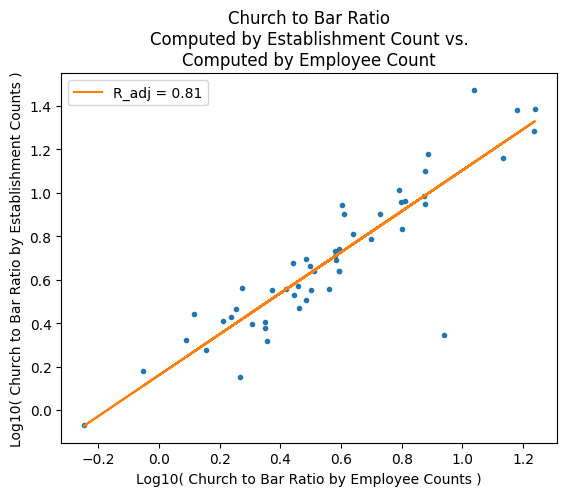

In [28]:
c2br.plot_ratio_vs()

## Review ratio histograms

In the above plot I compared the log-transformed values rather than the original values. Plotting histograms of the distributions of the ratio computations illustrates that the log-transformed values are much more evenly distributed:

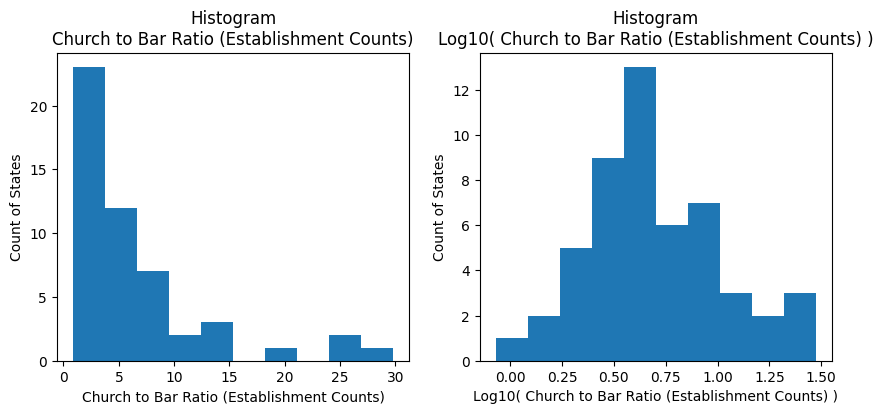

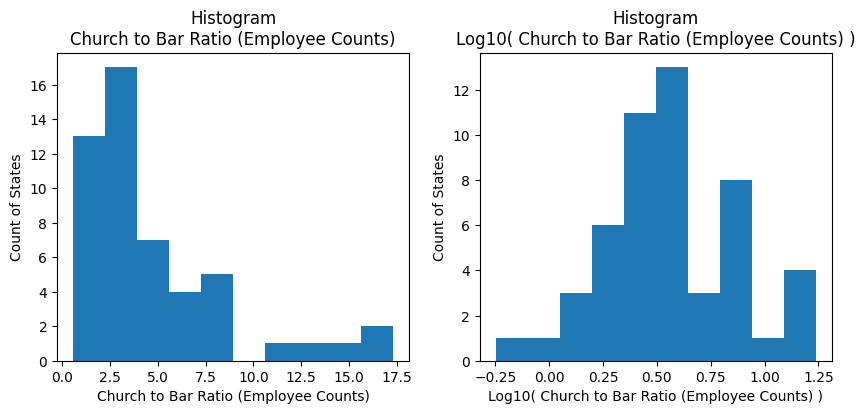

In [29]:
c2br.plot_ratio_histograms('est', 'Church to Bar Ratio (Establishment Counts)')
c2br.plot_ratio_histograms('emp', 'Church to Bar Ratio (Employee Counts)')

## Review count histograms

Good analysis practice dictates that we review the distributions of the count values used to perform the ratio calculations. I actually performed this task before computing the ratios discussed above (as one should!), but decided for the sake of this narrative to present the ratio computation analysis results first:

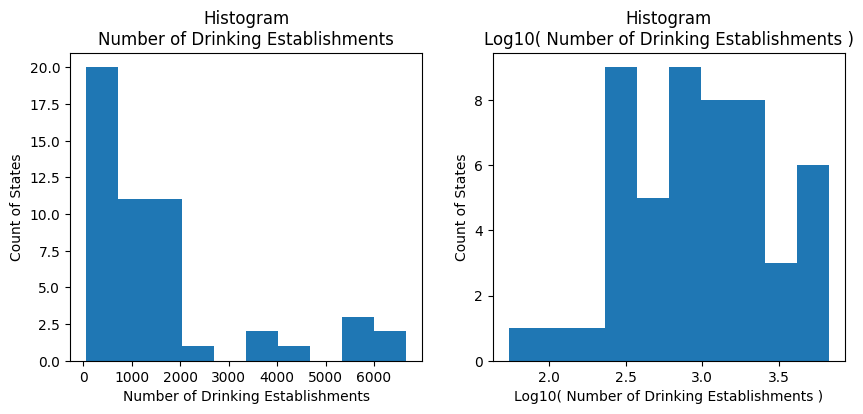

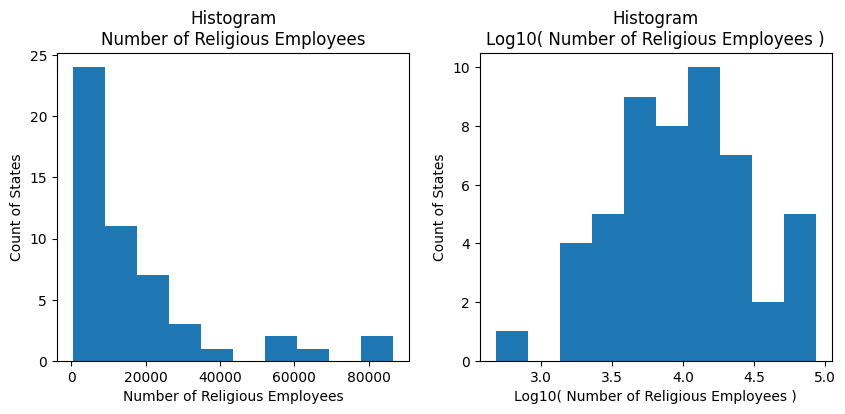

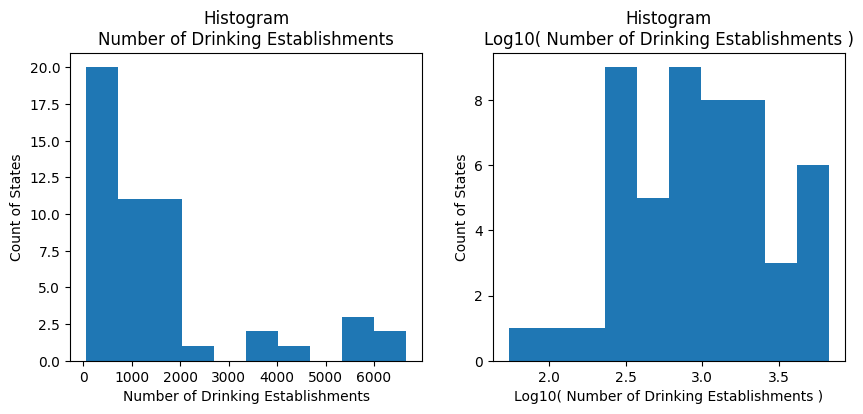

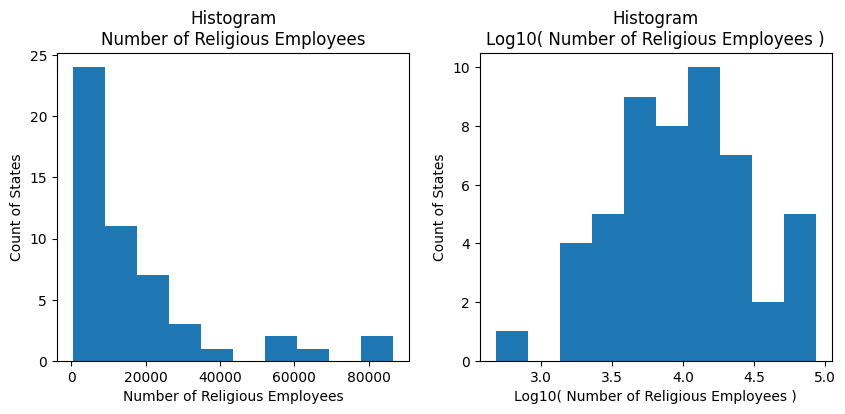

In [30]:
c2br.plot_count_histograms('est', 'drinking', 'Number of Drinking Establishments')
c2br.plot_count_histograms('emp', 'drinking', 'Number of Religious Employees')
c2br.plot_count_histograms('est', 'drinking', 'Number of Drinking Establishments')
c2br.plot_count_histograms('emp', 'drinking', 'Number of Religious Employees')

## Review count scatterplots

Similarly, good analysis practice requires that we investigate the counts with respect to each other to better understand our source data. Again, I performed this task before computing the ratios described above but for the sake of narrative presented the ratio results first:

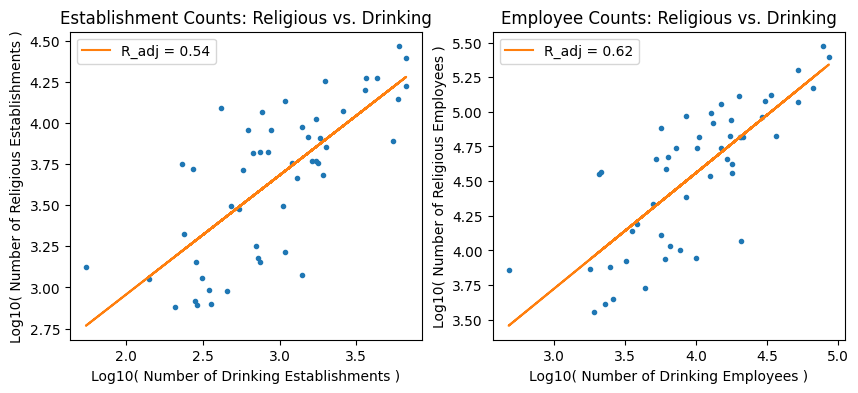

In [31]:
c2br.plot_counts_vs()

## Define the per-state color groups for the maps

In [32]:
c2br.define_color_group_cutpoints()
c2br.define_color_groups()

In [33]:
(
    c2br.df
    [['state', 'log10_c2br_emp', 'log10_c2br_est',
      'color_log10_c2br_emp', 'color_log10_c2br_est'
     ]]
).head(3)

,state,log10_c2br_emp,log10_c2br_est,color_log10_c2br_emp,color_log10_c2br_est
0,AL,1.132485,1.159882,#0eeaff,#0cc0db
1,AK,0.237591,0.428023,#05426e,#05426e
2,AZ,0.37333,0.553017,#076c92,#065780


## QA to ensure there are no missing color values for any state

In [34]:
c2br.run_qa_2()  # throws an exception if NaN values found

## Aggregate to create the CSS required to color in the states within the SVG file

In [35]:
c2br.create_color_css()

In [36]:
c2br.dict_state_color_lists['emp'].head(5)   # ratio computed using employee counts

,emp,state,css
0,#010338,[NV],.nv {fill:#010338}
1,#02184a,[MT],.mt {fill:#02184a}
2,#032d5c,"[DC, RI]",".dc,.ri {fill:#032d5c}"
3,#05426e,"[AK, ND, SD]",".ak,.nd,.sd {fill:#05426e}"
4,#065780,"[ID, IL, NY, OR, VT, WI, WY]",".id,.il,.ny,.or,.vt,.wi,.wy {fill:#065780}"


In [37]:
c2br.dict_state_color_lists['est'].head(5)   # ratio computed using establishment counts

,est,state,css
0,#010338,[NV],.nv {fill:#010338}
1,#02184a,"[MT, WI]",".mt,.wi {fill:#02184a}"
2,#032d5c,[ND],.nd {fill:#032d5c}
3,#05426e,"[AK, DC, ID, IL, NY, OR, RI, SD, UT]",".ak,.dc,.id,.il,.ny,.or,.ri,.sd,.ut {fill:#054..."
4,#065780,"[AZ, CA, CO, HI, IA, LA, NE, VT, WA, WY]",".az,.ca,.co,.hi,.ia,.la,.ne,.vt,.wa,.wy {fill:..."


## Color in the SVG maps and save them to disk

This produces SVG files for the log-transformed ratios, one file each for the case where the ratio is computed using employee counts and for the case where the ratio is computed using establishment counts:

In [38]:
c2br.create_SVG_maps()

## Convert the SVG maps to PNG format

In [39]:
for method_name in ['EST', 'EMP']:
    input_svg = directory_output + '/' + method_name + '_per_us_state_church_to_bar_ratio' + '.svg'
    output_png = directory_output + '/' + method_name + '_per_us_state_church_to_bar_ratio' + '.png'
    cairosvg.svg2png(url = input_svg, write_to = output_png)

## Display

#### Display by Establishment Counts

In [40]:
SVG(directory_output + '/EST_per_us_state_church_to_bar_ratio.svg')

#### Display by Employee Counts

In [41]:
SVG(directory_output + '/EMP_per_us_state_church_to_bar_ratio.svg')